<a href="https://colab.research.google.com/github/maishamehzabin/CSE475_Lab/blob/main/(2022_2_60_108)Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

Upload data set

In [ ]:
import os

# If running in this environment, dataset path might be:
path_candidates = [
    "/mnt/data/Mall_Customers.csv",   # this chat environment
    "/content/Mall_Customers.csv"     # typical Colab path
]

csv_path = None
for p in path_candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    # Colab fallback: upload the file manually
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]

df = pd.read_csv(csv_path)
df.head()

Saving Mall_Customers.csv to Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print(df.shape)
print(df.columns)
df.info()

(200, 5)
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Preprocess (encode Gender)

In [ ]:
df_proc = df.copy()

# Common column names in Mall_Customers.csv:
# ['CustomerID','Gender','Age','Annual Income (k$)','Spending Score (1-100)']

# Encode Gender (Female=0, Male=1)
if "Gender" in df_proc.columns:
    df_proc["Gender_num"] = df_proc["Gender"].map({"Female": 0, "Male": 1})
else:
    raise ValueError("No 'Gender' column found. Check your CSV column names.")

# Features for clustering/classification
drop_cols = [c for c in ["CustomerID", "Gender"] if c in df_proc.columns]
feature_cols = [c for c in df_proc.columns if c not in drop_cols + ["Gender_num"]]

X = df_proc[feature_cols].values
y = df_proc["Gender_num"].values  # label for k-NN classification

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_cols, X_scaled.shape

(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], (200, 3))

PCA (2D) for visualization

Explained variance ratio: [0.44266167 0.33308378]
Total explained variance: 0.7757454566976747


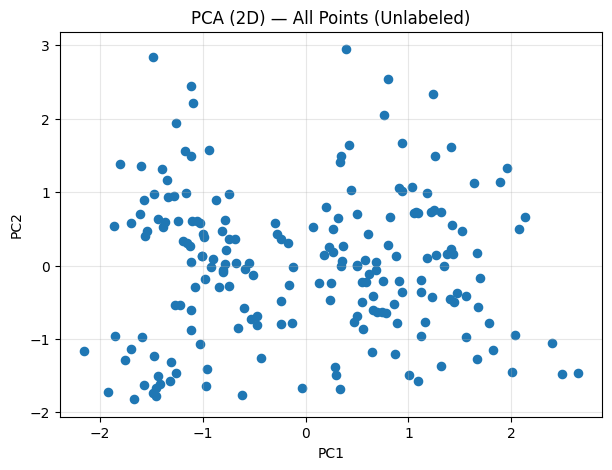

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=35)
plt.title("PCA (2D) — All Points (Unlabeled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

**KNN**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Choose k (simple default). You can tune later.
k = 7
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("k =", k)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

k = 7
Accuracy: 0.44

Confusion matrix:
 [[16 12]
 [16  6]]

Report:
               precision    recall  f1-score   support

           0       0.50      0.57      0.53        28
           1       0.33      0.27      0.30        22

    accuracy                           0.44        50
   macro avg       0.42      0.42      0.42        50
weighted avg       0.43      0.44      0.43        50



PCA plot colored by kNN predicted Gender

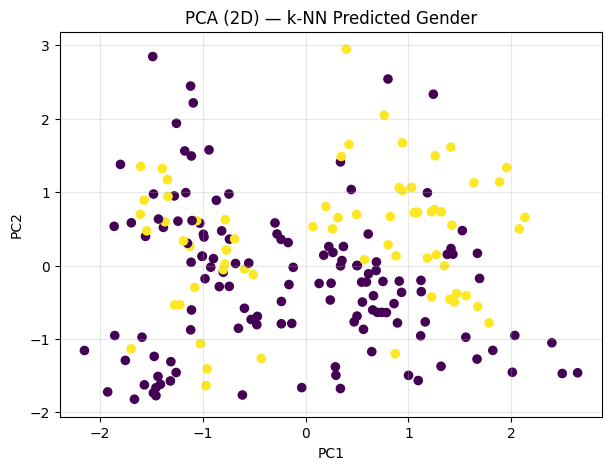

In [ ]:
# Predict for all points (not just test) for visualization
y_pred_all = knn.predict(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_all, s=35)
plt.title("PCA (2D) — k-NN Predicted Gender")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

DBSCAN (Clustering)

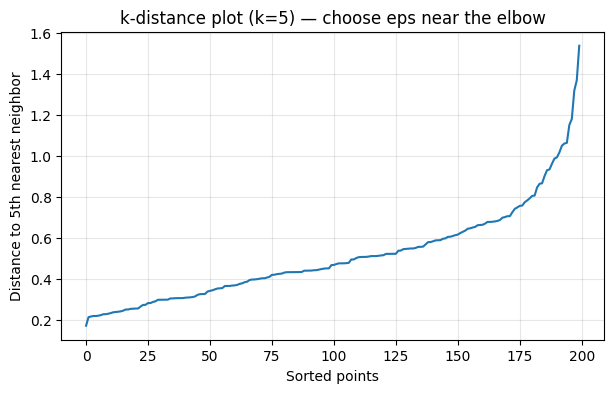

In [ ]:
# k-distance plot to help choose eps
k_neighbors = 5
nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X_scaled)

distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(7,4))
plt.plot(k_dist)
plt.title(f"k-distance plot (k={k_neighbors}) — choose eps near the elbow")
plt.xlabel("Sorted points")
plt.ylabel(f"Distance to {k_neighbors}th nearest neighbor")
plt.grid(True, alpha=0.3)
plt.show()

DBSCAN eps: 0.9 min_samples: 5
Clusters found: 1
Noise points: 3


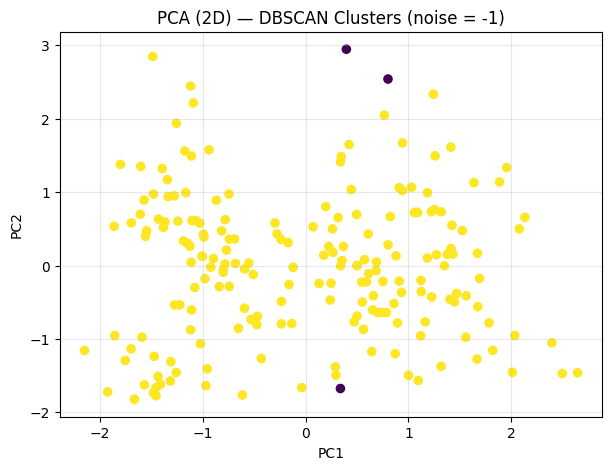

In [ ]:
# Set eps based on elbow you see above (start with something like 0.6~1.2)
eps = 0.9
min_samples = 5

db = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)

print("DBSCAN eps:", eps, "min_samples:", min_samples)
print("Clusters found:", n_clusters)
print("Noise points:", n_noise)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, s=35)
plt.title("PCA (2D) — DBSCAN Clusters (noise = -1)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

GMM (Clustering)

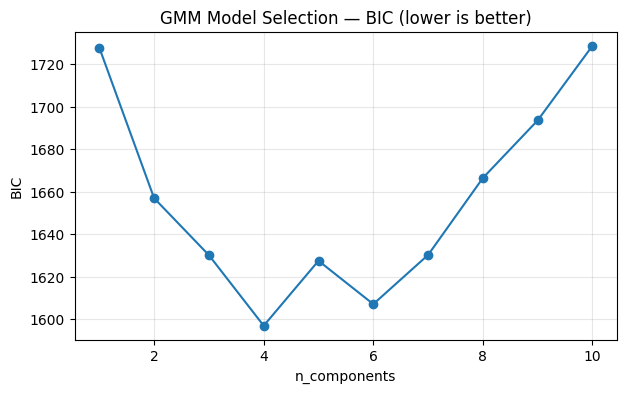

Best n_components by BIC: 4


In [ ]:
bics = []
aics = []
ks = range(1, 11)

for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

plt.figure(figsize=(7,4))
plt.plot(list(ks), bics, marker="o")
plt.title("GMM Model Selection — BIC (lower is better)")
plt.xlabel("n_components")
plt.ylabel("BIC")
plt.grid(True, alpha=0.3)
plt.show()

best_k = int(ks[np.argmin(bics)])
print("Best n_components by BIC:", best_k)

GMM components: 4


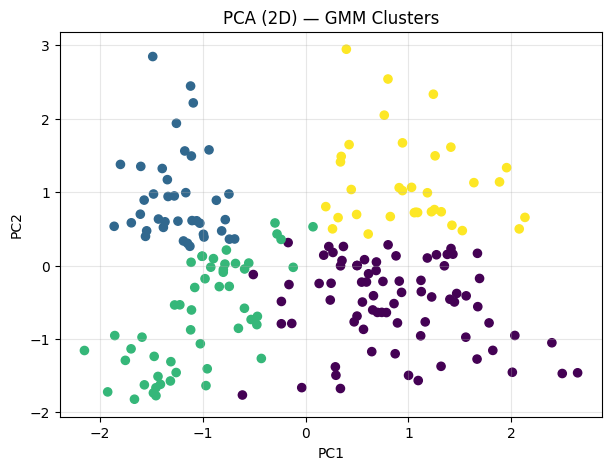

In [ ]:
gmm = GaussianMixture(n_components=best_k, covariance_type="full", random_state=42)
gmm.fit(X_scaled)

gmm_labels = gmm.predict(X_scaled)

print("GMM components:", best_k)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels, s=35)
plt.title("PCA (2D) — GMM Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()